# RL Group Project: Plots

## Clinical Treatment Optimisation: Sepsis ICU Management

**Master in Data Science & Advanced Analytics — Reinforcement Learning Course**

---

### Group Members

Group Q

```
Student 1: Diogo Carvalho - 20221935
Student 2: Ricardo Pereira - 20250343
Student 3: Yehor Malakhov - 20221691
```


In [ ]:
import warnings
from typing import TYPE_CHECKING

# if TYPE_CHECKING:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns

from envs.env_setup import (
    STATE_DIED,
    STATE_SURVIVED,
    make_sepsis_env,
)
from envs.wrappers import (
    make_clinical_env,
)

if TYPE_CHECKING:
    import icu_sepsis


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [ ]:
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

SEED = 42
np.random.seed(SEED)

ICU-Sepsis-v2 | States: 716 | Actions: 25
Terminal states: 714 (survived, r=+1)  713 (died, r=0)
Setup complete!


---

## Config A


In [3]:
#  Instantiate and inspect the raw environment
env = make_sepsis_env()
obs, info = env.reset(seed=SEED)

print(f"Observation space : {env.observation_space} discrete integer state")
print(f"Action space      : {env.action_space}")
print(f"Initial state     : {obs}")
print()

#  Extract the full MDP model

# pyright reports wrong type for env.unwrapped
raw: icu_sepsis.ICUSepsisEnv = env.unwrapped  # pyright: ignore[reportAssignmentType]
P: np.ndarray[tuple[int, int, int], np.dtype[np.float64]] = (
    raw._tx_mat
)  # shape (716, 25, 716) — P[s,a,s'] = P(s'|s,a)
R_sasp: np.ndarray[tuple[int, int, int], np.dtype[np.float64]] = (
    raw._r_mat
)  # (716, 25, 716) — R[s, a, s']
R: np.ndarray[tuple[int, int], np.dtype[np.float64]] = (P * R_sasp).sum(
    axis=2
)  # (716, 25)      — E[r | s, a]

print(f"Transition matrix P : {P.shape}  (S × A × S')")
print(f"Reward matrix R     : {R.shape}  (S × A)")
print(f"Reward range        : [{R.min():.3f}, {R.max():.3f}]")
print()

Observation space : Discrete(716) discrete integer state
Action space      : Discrete(25)
Initial state     : 559

Transition matrix P : (716, 25, 716)  (S × A × S')
Reward matrix R     : (716, 25)  (S × A)
Reward range        : [-0.020, 0.708]



In [4]:
#  Random baseline: establish the performance floor
def run_random_baseline(n_episodes=1000, seed=SEED):
    np.random.seed(seed)
    env_eval = make_sepsis_env()
    returns, lengths = [], []
    for _ in range(n_episodes):
        obs, _ = env_eval.reset(seed=np.random.randint(100_000))
        total_r, steps, done = 0.0, 0, False
        while not done:
            obs, r, te, tr, _ = env_eval.step(env_eval.action_space.sample())
            total_r += r
            steps += 1
            done = te or tr
        returns.append(total_r)
        lengths.append(steps)
    env_eval.close()
    return np.array(returns), np.array(lengths)


rand_returns, rand_lengths = run_random_baseline()
survival_rate = float(np.mean(rand_returns > 0)) * 100

print(f"Random agent ({len(rand_returns)} episodes):")
print(f"  Mean return    : {np.mean(rand_returns):.4f}")
print(f"  Survival rate  : {survival_rate:.1f}%")
print(f"  Mean ep length : {np.mean(rand_lengths):.1f} steps")
print()
print("All Config A algorithms must beat the random baseline.")

Random agent (1000 episodes):
  Mean return    : 0.5878
  Survival rate  : 69.0%
  Mean ep length : 10.3 steps

All Config A algorithms must beat the random baseline.


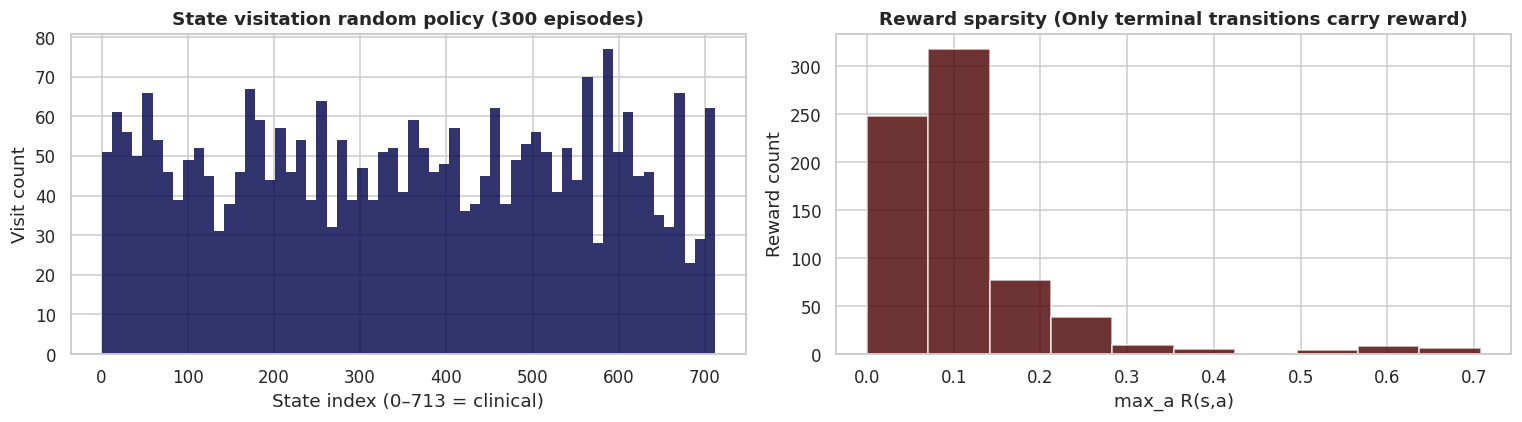

In [ ]:
#  Visualise state visitation and reward structure
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# State visitation under random policy
np.random.seed(SEED)
env_vis = make_sepsis_env()
visited = []
for _ in range(300):
    obs, _ = env_vis.reset(seed=np.random.randint(100_000))
    done = False
    while not done:
        visited.append(int(obs))
        obs, _, te, tr, _ = env_vis.step(env_vis.action_space.sample())
        done = te or tr
env_vis.close()
clinical = [s for s in visited if s not in (STATE_SURVIVED, STATE_DIED)]

axes[0].hist(clinical, bins=60, color="#00004A", edgecolor="none", alpha=0.8)
axes[0].set_xlabel("State index (0–713 = clinical)")
axes[0].set_ylabel("Visit count")
axes[0].set_title(
    "State visitation random policy (300 episodes)", fontweight="bold"
)

# Max achievable reward per state (only survival-adjacent states have r > 0)
axes[1].hist(R.max(axis=1), color="#4A0000", alpha=0.8)
axes[1].set_xlabel("max_a R(s,a)")
axes[1].set_ylabel("Reward count")
axes[1].set_title(
    "Reward sparsity (Only terminal transitions carry reward)",
    fontweight="bold",
)

plt.tight_layout()
plt.show()

### Policy Iteration


In [6]:
pi_returns = pl.read_csv("logs/pi_mean_return_eval.csv").to_numpy()
pi_lengths = pl.read_csv("logs/pi_episode_length_eval.csv").to_numpy()

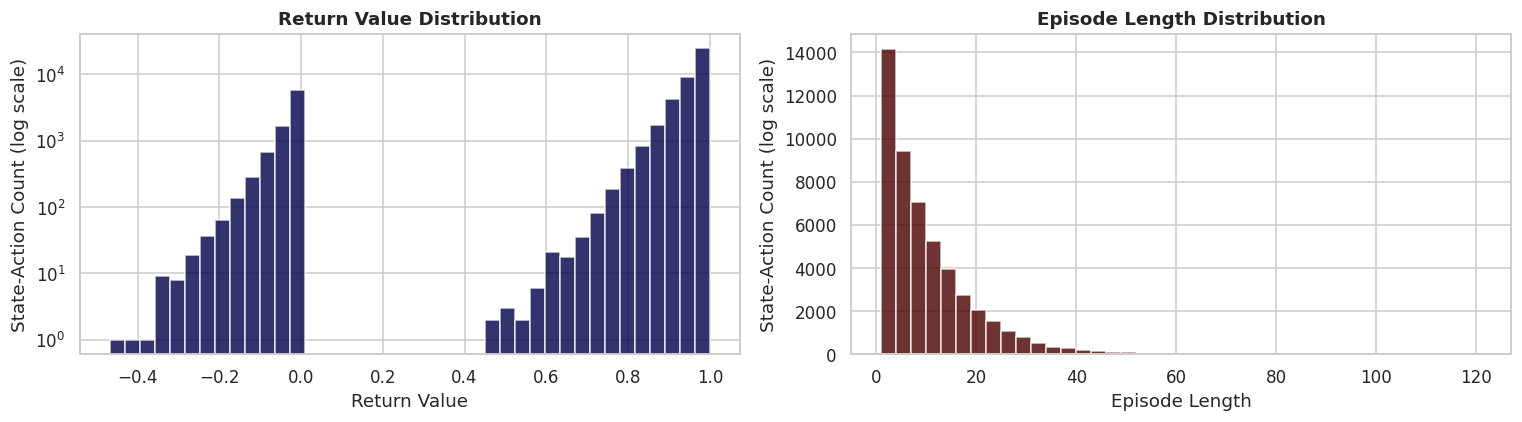

In [ ]:
#  Visualise state visitation and reward structure
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(pi_returns, bins=40, color="#00004A", alpha=0.8)
axes[0].set_yscale("log")
axes[0].set_xlabel("Return Value")
axes[0].set_ylabel("State-Action Count (log scale)")
axes[0].set_title("Return Value Distribution", fontweight="bold")

axes[1].hist(
    pi_lengths,
    color="#4A0000",
    alpha=0.8,
    bins=40,
)
axes[1].set_xlabel("Episode Length")
axes[1].set_ylabel("State-Action Count (log scale)")
axes[1].set_title("Episode Length Distribution", fontweight="bold")

plt.tight_layout()
plt.show()

### Q-Learning


In [8]:
q_ma = pl.read_csv("logs/ql_episode_returns_train.csv")[
    "column_0"
].rolling_mean(5000)
ql_ma = pl.read_csv("logs/ql_episode_length_train.csv")[
    "column_0"
].rolling_mean(5000)
q_mae = pl.read_csv("logs/ql_mean_return_eval.csv")["column_0"]
ql_mae = pl.read_csv("logs/ql_episode_length_eval.csv")["column_0"]

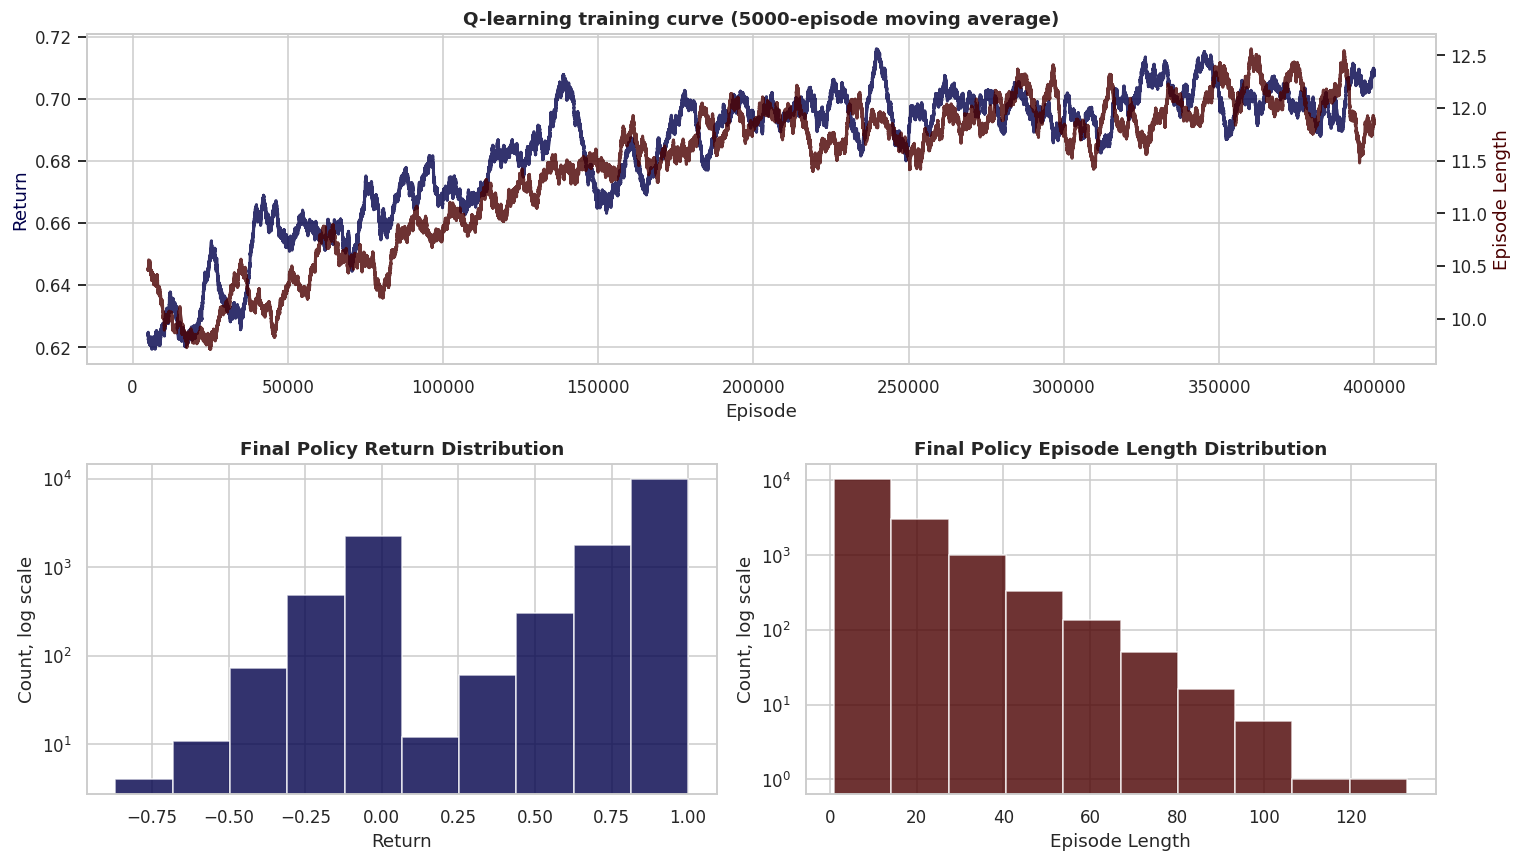

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].remove()
axes[0, 1].remove()

ax0 = fig.add_subplot(2, 1, 1)

parax0 = ax0.twinx()
# axes[1].set_yscale("log")
ax0.plot(q_ma, color="#00004A", linewidth=2, alpha=0.8)
ax0.set_title(
    "Q-learning training curve (5000-episode moving average)",
    fontweight="bold",
)
ax0.set_xlabel("Episode")
ax0.set_ylabel("Return", color="#00004A")

parax0.plot(ql_ma, color="#4A0000", linewidth=2, alpha=0.8)
parax0.set_ylabel("Episode Length", color="#4A0000")
parax0.yaxis.grid(False, which="both")

axes[1, 0].hist(q_mae, color="#00004A", alpha=0.8)
axes[1, 0].set_title("Final Policy Return Distribution", fontweight="bold")
axes[1, 0].set_xlabel("Return")
axes[1, 0].set_ylabel("Count, log scale")
axes[1, 0].set_yscale("log")

axes[1, 1].hist(ql_mae, color="#4A0000", alpha=0.8)
axes[1, 1].set_title(
    "Final Policy Episode Length Distribution", fontweight="bold"
)
axes[1, 1].set_xlabel("Episode Length")
axes[1, 1].set_ylabel("Count, log scale")
axes[1, 1].set_yscale("log")

plt.tight_layout()
plt.show()

## Config A Comparison


In [10]:
if "rand_returns" in globals():
    random_returns = np.asarray(rand_returns)
elif "run_random_baseline" in globals():
    random_returns, _ = run_random_baseline(n_episodes=200)
else:
    random_returns = None

if random_returns is not None:
    random_mean = float(np.mean(random_returns))
else:
    random_mean = np.nan
    print(
        "Random baseline was not available in the current kernel; run the earlier baseline cell to populate that comparison."
    )

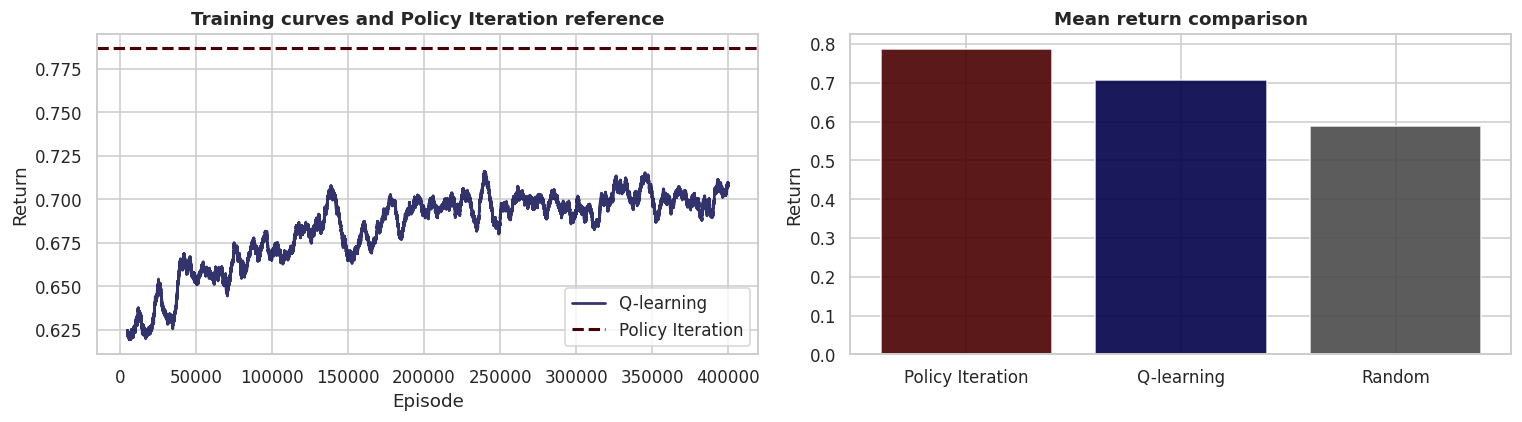

In [ ]:
policy_iteration_mean = float(pi_returns.mean())
q_learning_mean = float(q_mae.to_numpy().mean())


fig, axes = plt.subplots(1, 2, figsize=(14, 4))


axes[0].plot(
    q_ma, color="#00004A", linewidth=1.8, label="Q-learning", alpha=0.8
)
axes[0].axhline(
    policy_iteration_mean,
    color="#4A0000",
    linestyle="--",
    linewidth=2,
    label="Policy Iteration",
)
axes[0].set_title(
    "Training curves and Policy Iteration reference", fontweight="bold"
)
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Return")
axes[0].legend()


axes[1].bar(
    ["Policy Iteration", "Q-learning", "Random"],
    [policy_iteration_mean, q_learning_mean, random_mean],
    color=["#4A0000", "#00004A", "#4A4A4A"],
    alpha=0.9,
)
axes[1].set_title("Mean return comparison", fontweight="bold")
axes[1].set_ylabel("Return")


plt.tight_layout()
plt.show()

---

# Config B


In [12]:
#  Verify wrappers and random baseline on clinical environment
env_clinical = make_clinical_env()
obs, info = env_clinical.reset(seed=SEED)

# Random baseline on clinical env (1000 episodes)
np.random.seed(SEED)
clinical_rand_returns = []

env_eval = make_clinical_env()
for _ in range(1000):
    obs, info = env_eval.reset(seed=np.random.randint(100_000))
    total_r, done = 0.0, False
    ep_noisy = info.get("noisy_episode", False)
    ep_missing = info.get("missing_features") is not None
    ep_acute = False

    while not done:
        obs, r, te, tr, info = env_eval.step(env_eval.action_space.sample())
        total_r += r
        done = te or tr
        if info.get("acute_event", False):
            ep_acute = True

    clinical_rand_returns.append(total_r)

env_eval.close()
env_clinical.close()

print()
print("=== Random Baseline: Clinical Environment (1000 episodes) ===")
print(f"Overall mean return   : {np.mean(clinical_rand_returns):.4f}")
print(
    f"Overall survival rate : {np.mean(np.array(clinical_rand_returns) > 0) * 100:.1f}%"
)
print()

# Store for later comparison
clinical_rand_mean = float(np.mean(clinical_rand_returns))


=== Random Baseline: Clinical Environment (1000 episodes) ===
Overall mean return   : 0.5685
Overall survival rate : 66.5%



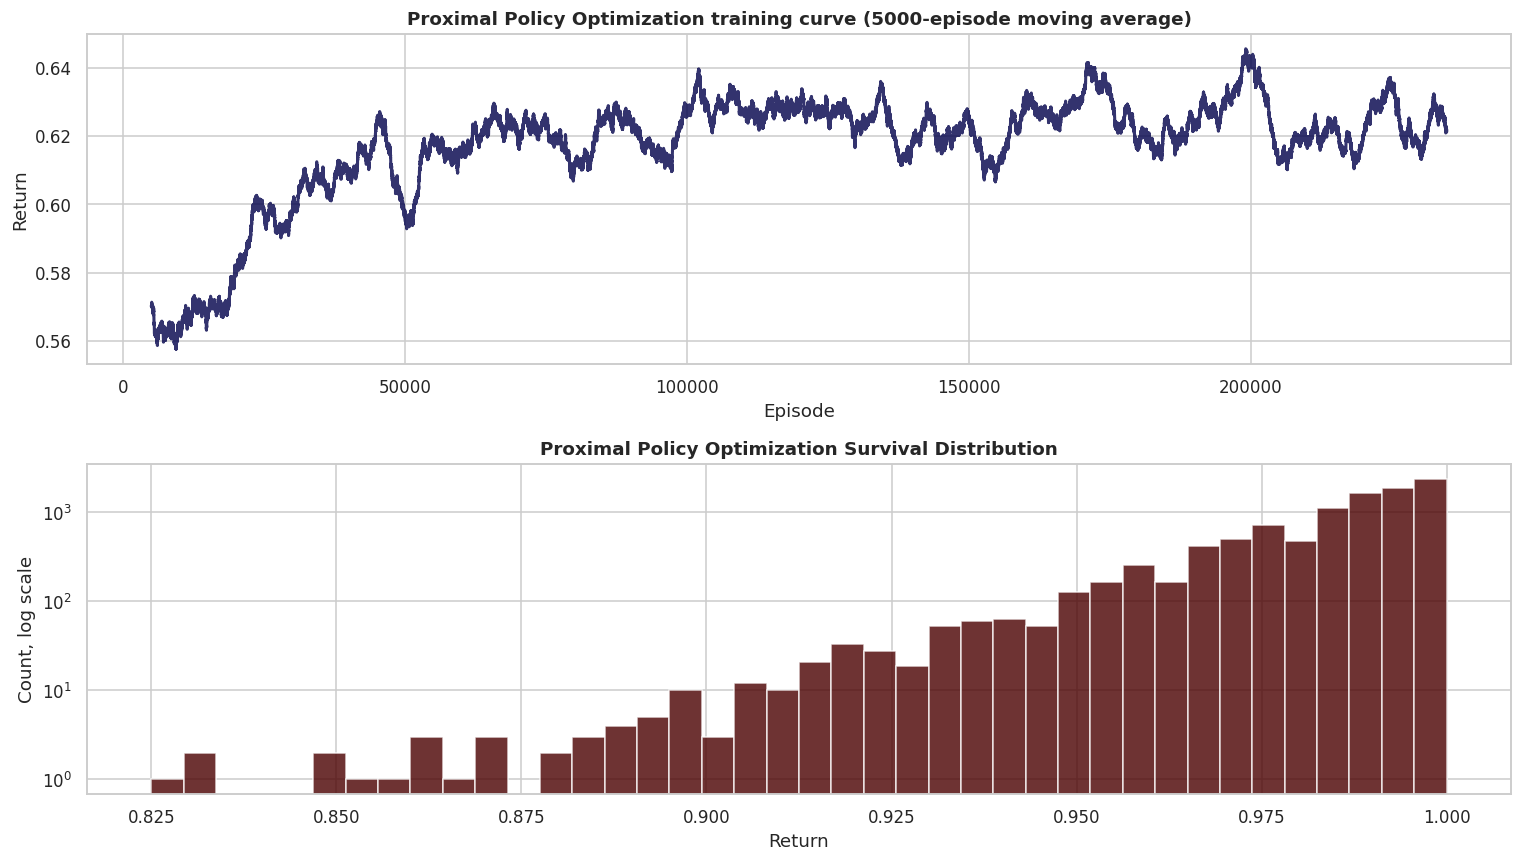

In [13]:
fig, ax = plt.subplots(2, 1, figsize=(14, 8))
nw = 5000

ax[0].plot(
    pl.read_csv("logs/ppo_episode_returns_train.csv")["column_0"].rolling_mean(
        nw
    ),
    color="#00004A",
    linewidth=2,
    alpha=0.8,
)
ax[0].set_xlabel("Episode")
ax[0].set_ylabel("Return")
ax[0].set_title(
    f"Proximal Policy Optimization training curve ({nw}-episode moving average)",
    fontweight="bold",
)

ax[1].hist(
    pl.read_csv("logs/ppo_mean_return_eval.csv").filter(pl.col("column_0") > 0)[
        "column_0"
    ],
    edgecolor="white",
    bins=40,
    color="#4A0000",
    alpha=0.8,
)
ax[1].set_xlabel("Return")
ax[1].set_ylabel("Count, log scale")
ax[1].set_yscale("log")
ax[1].set_title(
    "Proximal Policy Optimization Survival Distribution", fontweight="bold"
)

plt.tight_layout()
plt.show()

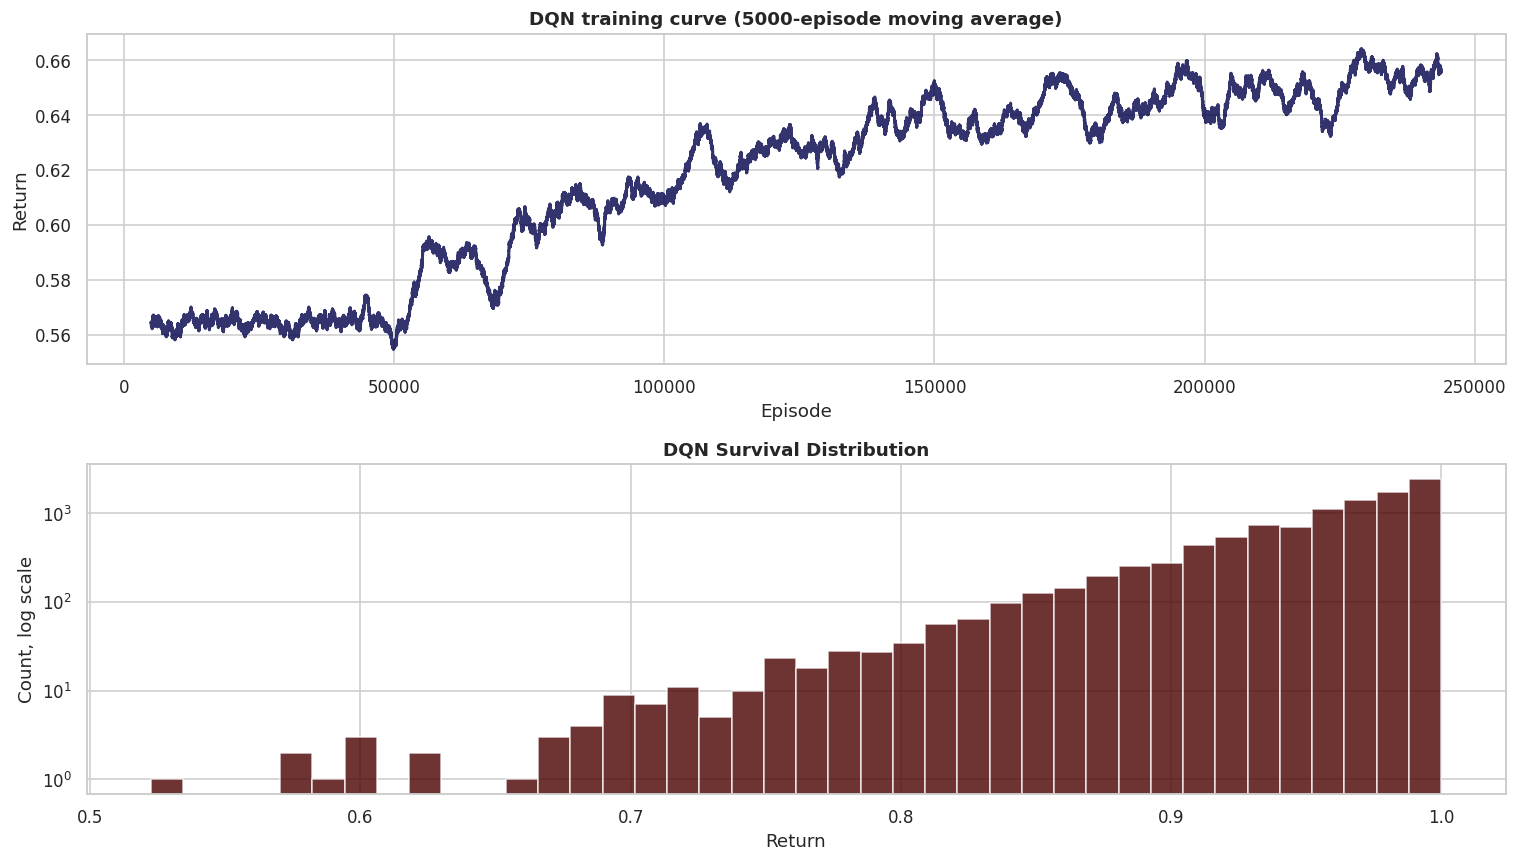

In [14]:
fig, ax = plt.subplots(2, 1, figsize=(14, 8))
nw = 5000

ax[0].plot(
    pl.read_csv("logs/dqn_episode_returns_train.csv")["column_0"].rolling_mean(
        nw
    ),
    color="#00004A",
    linewidth=2,
    alpha=0.8,
)
ax[0].set_xlabel("Episode")
ax[0].set_ylabel("Return")
ax[0].set_title(
    f"DQN training curve ({nw}-episode moving average)", fontweight="bold"
)

ax[1].hist(
    pl.read_csv("logs/dqn_mean_return_eval.csv").filter(pl.col("column_0") > 0)[
        "column_0"
    ],
    edgecolor="white",
    bins=40,
    color="#4A0000",
    alpha=0.8,
)
ax[1].set_xlabel("Return")
ax[1].set_ylabel("Count, log scale")
ax[1].set_yscale("log")
ax[1].set_title(
    f"DQN Average Performance ({nw}-episode moving average)", fontweight="bold"
)
ax[1].set_title("DQN Survival Distribution", fontweight="bold")

plt.tight_layout()
plt.show()

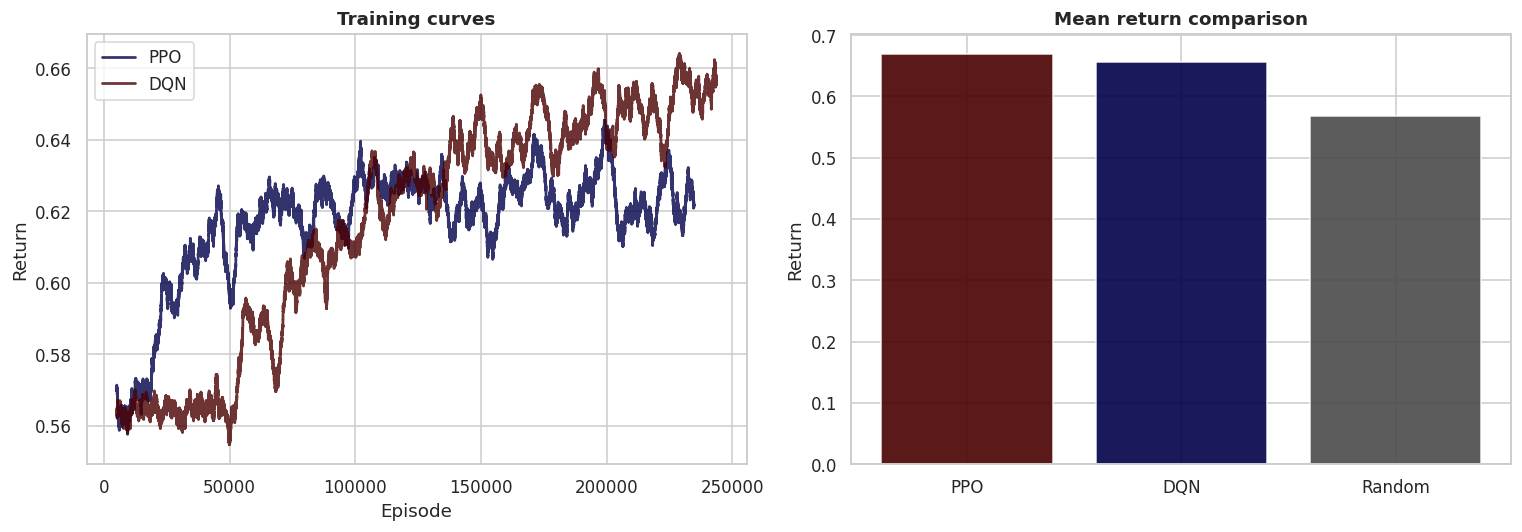

In [ ]:
ppo_mean = float(
    pl.read_csv("logs/ppo_mean_return_eval.csv")["column_0"].mean()
)
dqn_learning_mean = float(
    pl.read_csv("logs/dqn_mean_return_eval.csv")["column_0"].mean()
)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))


axes[0].plot(
    pl.read_csv("logs/ppo_episode_returns_train.csv", has_header=False)[
        "column_1"
    ].rolling_mean(nw),
    color="#00004A",
    linewidth=1.8,
    label="PPO",
    alpha=0.8,
)
axes[0].plot(
    pl.read_csv("logs/dqn_episode_returns_train.csv", has_header=False)[
        "column_1"
    ].rolling_mean(nw),
    color="#4A0000",
    linewidth=1.8,
    label="DQN",
    alpha=0.8,
)

axes[0].set_title("Training curves", fontweight="bold")
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Return")
axes[0].legend()


axes[1].bar(
    ["PPO", "DQN", "Random"],
    [ppo_mean, dqn_learning_mean, clinical_rand_mean],
    color=["#4A0000", "#00004A", "#4A4A4A"],
    alpha=0.9,
)
axes[1].set_title("Mean return comparison", fontweight="bold")
axes[1].set_ylabel("Return")


plt.tight_layout()
plt.show()